In [1]:
from pathlib import Path
import os
import shutil

import h5py
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import ras_commander
from ras_commander import (
    HdfResultsPlan,
    RasCmdr,
    RasExamples,
    RasFloodway,
    RasPlan,
    init_ras_project,
)

## Development Mode

When running this notebook from a source checkout instead of an installed package, start Jupyter from the repository root or add the repository root to `PYTHONPATH` before launching Jupyter. Generated example projects and run outputs are written under `working/` unless `RAS_COMMANDER_WORKDIR` is set.

# Steady Floodway Encroachment Authoring

This notebook demonstrates the steady-flow floodway authoring API on the official HEC-RAS "Example 6 - Floodway Determination" project. It parses existing encroachment records, authors Method 1 through Method 5 plans without GUI steps, computes those plans through `RasCmdr`, validates a computed floodway profile through `RasCheck`, and compares floodway widths across methods.

HEC-RAS exposes five floodplain encroachment methods. HEC-2 method 6 energy targeting is represented in HEC-RAS by Method 5 with a maximum energy-change target.

In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "ras_commander").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
WORK_ROOT = Path(os.environ.get(
    "RAS_COMMANDER_WORKDIR",
    REPO_ROOT / "working" / "floodway_encroachment",
))
PROJECT_NAME = "Example 6 - Floodway Determination"
RAS_EXE = Path(os.environ.get(
    "HECRAS_EXE",
    r"C:/Program Files (x86)/HEC/HEC-RAS/7.0/Ras.exe",
))

assert RAS_EXE.exists(), f"HEC-RAS executable not found: {RAS_EXE}"

WORK_ROOT.mkdir(parents=True, exist_ok=True)
project_path = RasExamples.extract_project(
    PROJECT_NAME,
    output_path=WORK_ROOT,
    suffix="api_authoring",
)
ras_project = init_ras_project(project_path, str(RAS_EXE), load_results_summary=False)

print(f"ras-commander: {ras_commander.__version__}")
print(f"Project: {ras_project.project_name}")
print(f"Project folder: {ras_project.project_folder}")
display(ras_project.plan_df[["plan_number", "Plan Title", "Flow File", "Geom File"]])

2026-05-01 17:07:42 - ras_commander.RasExamples - INFO - Found zip file: C:\Users\billk_clb\AppData\Local\ras-commander\examples\Example_Projects_7_0.zip


2026-05-01 17:07:42 - ras_commander.RasExamples - INFO - Loading project data from CSV...


2026-05-01 17:07:42 - ras_commander.RasExamples - INFO - Loaded 67 projects from CSV.


2026-05-01 17:07:42 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Project -----


2026-05-01 17:07:42 - ras_commander.RasExamples - INFO - Extracting project 'Example 6 - Floodway Determination' as 'Example 6 - Floodway Determination_api_authoring'


...

2026-05-01 17:07:42 - ras_commander.RasPrj - INFO - ras-commander v0.96.1 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://ras-commander.readthedocs.io | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-05-01 17:07:42 - ras_commander.RasPrj - INFO - Project initialized: FLODENCR | Folder: H:\Symphony\ras-commander\CLB-307\notebook_runs\223_steady_floodway_encroachment\Example 6 - Floodway Determination_api_authoring


2026-05-01 17:07:42 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe


ras-commander: 0.96.1
Project: FLODENCR
Project folder: H:\Symphony\ras-commander\CLB-307\notebook_runs\223_steady_floodway_encroachment\Example 6 - Floodway Determination_api_authoring


,plan_number,Plan Title,Flow File,Geom File
0,01,Method 5 Encroachment,01,01
1,05,Method 1 Encroachment,01,01
2,02,Method 4 Encroachment - Trial 1,02,01
3,04,Method 4 Encroachment - Trial 3,01,01
4,03,Method 4 Encroachment - Trial 2,01,01


## Existing Encroachment Records

The example project already contains Method 1, Method 4, and Method 5 records. These are parsed from plan text before any new authoring.

In [3]:
existing_frames = []
for plan_number in ["01", "02", "05"]:
    parsed = RasFloodway.parse_encroachments(plan_number, ras_object=ras_project).copy()
    parsed["plan_number"] = plan_number
    parsed["plan_title"] = RasPlan.get_plan_title(plan_number, ras_object=ras_project)
    existing_frames.append(parsed)

existing_encroachments = pd.concat(existing_frames, ignore_index=True)
summary = (
    existing_encroachments
    .groupby(["plan_number", "plan_title", "method"], dropna=False)
    .size()
    .reset_index(name="records")
)
display(summary)
display(
    existing_encroachments[
        ["plan_number", "river", "reach", "node", "profile_number", "method", "value_1", "value_2"]
    ].head(18)
)

2026-05-01 17:07:42 - ras_commander.RasPlan - INFO - Retrieved Plan Title: Method 5 Encroachment


2026-05-01 17:07:42 - ras_commander.RasPlan - INFO - Retrieved Plan Title: Method 4 Encroachment - Trial 1


2026-05-01 17:07:42 - ras_commander.RasPlan - INFO - Retrieved Plan Title: Method 1 Encroachment


,plan_number,plan_title,method,records
0,01,Method 5 Encroachment,5.0,13
1,02,Method 4 Encroachment - Trial 1,0.0,24
2,02,Method 4 Encroachment - Trial 1,1.0,2
3,02,Method 4 Encroachment - Trial 1,4.0,26
4,02,Method 4 Encroachment - Trial 1,NaN,26
5,05,Method 1 Encroachment,1.0,13
6,05,Method 1 Encroachment,4.0,13


,plan_number,river,reach,node,profile_number,method,value_1,value_2
0,01,Beaver Creek,Kentwood,5.99,2,5.0,1.0,1.2
1,01,Beaver Creek,Kentwood,5.875*,2,5.0,1.0,1.2
2,01,Beaver Creek,Kentwood,5.76,2,5.0,1.0,1.2
3,01,Beaver Creek,Kentwood,5.685*,2,5.0,1.0,1.2
4,01,Beaver Creek,Kentwood,5.61,2,5.0,1.0,1.2
5,01,Beaver Creek,Kentwood,5.49*,2,5.0,1.0,1.2
6,01,Beaver Creek,Kentwood,5.41,2,5.0,1.0,1.2
7,01,Beaver Creek,Kentwood,5.4,2,5.0,1.0,1.2
8,01,Beaver Creek,Kentwood,5.39,2,5.0,1.0,1.2
9,01,Beaver Creek,Kentwood,5.24*,2,5.0,1.0,1.2


## Author Method 1-5 Plans

The cloned plans keep the original example project intact. Method 4 and Method 5 clone their own steady-flow files, then `RasFloodway` creates new floodway profiles and downstream starting WSE values.

In [4]:
def clean_station(value) -> float:
    return float(str(value).replace("*", "").strip())


def hdf_plan_path(plan_number: str) -> Path:
    return Path(ras_project.project_folder) / f"{ras_project.project_name}.p{plan_number}.hdf"


def hdf_geom_path() -> Path:
    return Path(ras_project.project_folder) / f"{ras_project.project_name}.g01.hdf"


def clone_plan(template_plan: str, title: str, shortid: str) -> str:
    return RasPlan.clone_plan(
        template_plan,
        new_title=title,
        new_plan_shortid=shortid,
        ras_object=ras_project,
    )


def clone_steady(template_flow: str, title: str) -> str:
    return RasPlan.clone_steady(
        template_flow,
        new_title=title,
        ras_object=ras_project,
    )


source_m1 = RasFloodway.parse_encroachments("05", ras_object=ras_project)
method1_records = (
    source_m1[(source_m1["reach"] == "Kentwood") & (source_m1["method"] == 1)]
    [["river", "reach", "node", "method", "left_station", "right_station"]]
    .to_dict("records")
)
locations = [
    {"river": row["river"], "reach": row["reach"], "node": row["node"]}
    for row in method1_records
]

method2_records = [
    {
        "river": row["river"],
        "reach": row["reach"],
        "node": row["node"],
        "method": 2,
        "fixed_top_width": row["right_station"] - row["left_station"],
    }
    for row in method1_records
]

method3_records = [
    {
        "river": row["river"],
        "reach": row["reach"],
        "node": row["node"],
        "method": 3,
        "conveyance_reduction_percent": 25,
    }
    for row in method1_records
]

plan_m1 = clone_plan("05", "API Method 1 Stations", "API_M1")
RasFloodway.set_encroachments(
    plan_m1,
    method1_records,
    encroach_param=(-1, 10, 10),
    profile_count=2,
    ras_object=ras_project,
)

plan_m2 = clone_plan("05", "API Method 2 Width", "API_M2")
RasFloodway.set_encroachments(
    plan_m2,
    method2_records,
    encroach_param=(-1, 10, 10),
    profile_count=2,
    ras_object=ras_project,
)

plan_m3 = clone_plan("05", "API Method 3 Conveyance", "API_M3")
RasFloodway.set_encroachments(
    plan_m3,
    method3_records,
    encroach_param=(-1, 10, 10),
    profile_count=2,
    ras_object=ras_project,
)

flow_m4 = clone_steady("01", "API Method 4 Flow")
plan_m4 = clone_plan("05", "API Method 4 Trials", "API_M4")
RasPlan.set_steady(plan_m4, flow_m4, ras_object=ras_project)
m4_result = RasFloodway.create_method_4_trial_profiles(
    plan_m4,
    targets=[0.5, 1.0],
    flow_number_or_path=flow_m4,
    base_profile=1,
    profile_names=["M4 0.5 ft", "M4 1.0 ft"],
    locations=locations,
    starting_wse_deltas=[0.5, 1.0],
    metadata={"notebook": "223_steady_floodway_encroachment"},
    ras_object=ras_project,
)

flow_m5 = clone_steady("01", "API Method 5 Flow")
plan_m5 = clone_plan("05", "API Method 5 Energy", "API_M5")
RasPlan.set_steady(plan_m5, flow_m5, ras_object=ras_project)
m5_result = RasFloodway.create_method_5_trial_profiles(
    plan_m5,
    targets=[0.5, 1.0],
    flow_number_or_path=flow_m5,
    base_profile=1,
    profile_names=["M5 0.5 ft", "M5 1.0 ft"],
    locations=locations,
    starting_wse_deltas=[0.5, 1.0],
    energy_targets=[0.25, 0.25],
    metadata={"notebook": "223_steady_floodway_encroachment"},
    ras_object=ras_project,
)

authored_plans = {
    "Method 1": {"plan": plan_m1, "floodway_profile": "PF#2"},
    "Method 2": {"plan": plan_m2, "floodway_profile": "PF#2"},
    "Method 3": {"plan": plan_m3, "floodway_profile": "PF#2"},
    "Method 4 0.5 ft": {"plan": plan_m4, "floodway_profile": "M4 0.5 ft"},
    "Method 4 1.0 ft": {"plan": plan_m4, "floodway_profile": "M4 1.0 ft"},
    "Method 5 0.5 ft": {"plan": plan_m5, "floodway_profile": "M5 0.5 ft"},
    "Method 5 1.0 ft": {"plan": plan_m5, "floodway_profile": "M5 1.0 ft"},
}

setup_preview = []
for label, info in authored_plans.items():
    enc = RasFloodway.parse_encroachments(info["plan"], ras_object=ras_project)
    methods = sorted(enc.loc[enc["method"] > 0, "method"].dropna().unique().astype(int).tolist())
    setup_preview.append({
        "label": label,
        "plan": info["plan"],
        "floodway_profile": info["floodway_profile"],
        "methods_written": methods,
        "records": int((enc["method"] > 0).sum()),
    })

display(pd.DataFrame(setup_preview))
display(m4_result["encroachments"].head())

2026-05-01 17:07:42 - ras_commander.RasUtils - INFO - File cloned from H:\Symphony\ras-commander\CLB-307\notebook_runs\223_steady_floodway_encroachment\Example 6 - Floodway Determination_api_authoring\FLODENCR.p05 to H:\Symphony\ras-commander\CLB-307\notebook_runs\223_steady_floodway_encroachment\Example 6 - Floodway Determination_api_authoring\FLODENCR.p06


2026-05-01 17:07:42 - ras_commander.RasUtils - INFO - Successfully updated file: H:\Symphony\ras-commander\CLB-307\notebook_runs\223_steady_floodway_encroachment\Example 6 - Floodway Determination_api_authoring\FLODENCR.p06


2026-05-01 17:07:42 - ras_commander.RasUtils - INFO - Project file updated with new Plan entry: 06


2026-05-01 17:07:42 - ras_commander.RasPrj - INFO - No unsteady flow files found in the project.


2026-05-01 17:07:42 - ras_commander.RasMap - WARNING - RASMapper file not found: H:\Symphony\ras-commander\CLB-307\notebook_runs\223_steady_floodway_encroachment\Example 6 - Floodway Determination_api_authoring\FLODENCR.rasmap


...

2026-05-01 17:07:43 - ras_commander.RasPrj - WARNING - Could not resolve project CRS for H:\Symphony\ras-commander\CLB-307\notebook_runs\223_steady_floodway_encroachment\Example 6 - Floodway Determination_api_authoring


2026-05-01 17:07:43 - ras_commander.RasPrj - INFO - Updated results_df with 10 plan(s)


2026-05-01 17:07:43 - ras_commander.RasUtils - INFO - Successfully updated file: H:\Symphony\ras-commander\CLB-307\notebook_runs\223_steady_floodway_encroachment\Example 6 - Floodway Determination_api_authoring\FLODENCR.p10


,label,plan,floodway_profile,methods_written,records
0,Method 1,06,PF#2,[1],13
1,Method 2,07,PF#2,[2],13
2,Method 3,08,PF#2,[3],13
3,Method 4 0.5 ft,09,M4 0.5 ft,[4],26
4,Method 4 1.0 ft,09,M4 1.0 ft,[4],26
5,Method 5 0.5 ft,10,M5 0.5 ft,[5],26
6,Method 5 1.0 ft,10,M5 1.0 ft,[5],26


,river,reach,node,profile_number,profile_slot,method,value_1,value_2,left_station,right_station,target_top_width,conveyance_reduction_percent,target_surcharge,energy_target,encroach_param_1,encroach_param_2,encroach_param_3,profile_count,plan_path,line_number
0,Beaver Creek,Kentwood,5.99,2,1,0,0.0,0.0,None,None,None,None,NaN,None,-1.0,0.0,0.0,4.0,H:\Symphony\ras-commander\CLB-307\notebook_run...,22
1,Beaver Creek,Kentwood,5.99,3,2,4,0.5,0.0,None,None,None,None,0.5,None,-1.0,0.0,0.0,4.0,H:\Symphony\ras-commander\CLB-307\notebook_run...,22
2,Beaver Creek,Kentwood,5.99,4,3,4,1.0,0.0,None,None,None,None,1.0,None,-1.0,0.0,0.0,4.0,H:\Symphony\ras-commander\CLB-307\notebook_run...,22
3,Beaver Creek,Kentwood,5.875*,2,1,0,0.0,0.0,None,None,None,None,NaN,None,-1.0,0.0,0.0,4.0,H:\Symphony\ras-commander\CLB-307\notebook_run...,24
4,Beaver Creek,Kentwood,5.875*,3,2,4,0.5,0.0,None,None,None,None,0.5,None,-1.0,0.0,0.0,4.0,H:\Symphony\ras-commander\CLB-307\notebook_run...,24


## Encroachment Targets On Profile

The target markers are the Method 4 target WSEs, calculated as base-profile WSE plus the authored target surcharge at each encroached river station.

2026-05-01 17:07:43 - ras_commander.RasCmdr - INFO - Using ras_object with project folder: H:\Symphony\ras-commander\CLB-307\notebook_runs\223_steady_floodway_encroachment\Example 6 - Floodway Determination_api_authoring


2026-05-01 17:07:44 - ras_commander.geom.GeomPreprocessor - INFO - Clearing geometry preprocessor file for single plan: H:\Symphony\ras-commander\CLB-307\notebook_runs\223_steady_floodway_encroachment\Example 6 - Floodway Determination_api_authoring\FLODENCR.p06


2026-05-01 17:07:44 - ras_commander.geom.GeomPreprocessor - WARNING - No geometry preprocessor file found for: H:\Symphony\ras-commander\CLB-307\notebook_runs\223_steady_floodway_encroachment\Example 6 - Floodway Determination_api_authoring\FLODENCR.p06


2026-05-01 17:07:44 - ras_commander.geom.GeomPreprocessor - INFO - Geometry dataframe updated successfully.


2026-05-01 17:07:44 - ras_commander.RasCmdr - INFO - Cleared geometry preprocessor files for plan: 06


...

2026-05-01 17:08:02 - ras_commander.hdf.HdfResultsPlan - INFO - Final validated file path: H:\Symphony\ras-commander\CLB-307\notebook_runs\223_steady_floodway_encroachment\Example 6 - Floodway Determination_api_authoring\FLODENCR.p10.hdf


2026-05-01 17:08:02 - ras_commander.RasPrj - INFO - Updated results_df with 1 plan(s)


2026-05-01 17:08:02 - ras_commander.hdf.HdfResultsPlan - INFO - Using existing Path object HDF file: H:\Symphony\ras-commander\CLB-307\notebook_runs\223_steady_floodway_encroachment\Example 6 - Floodway Determination_api_authoring\FLODENCR.p09.hdf


2026-05-01 17:08:02 - ras_commander.hdf.HdfResultsPlan - INFO - Final validated file path: H:\Symphony\ras-commander\CLB-307\notebook_runs\223_steady_floodway_encroachment\Example 6 - Floodway Determination_api_authoring\FLODENCR.p09.hdf


2026-05-01 17:08:02 - ras_commander.hdf.HdfResultsPlan - INFO - Extracted steady results: 48 rows (4 profiles x 12 cross sections)


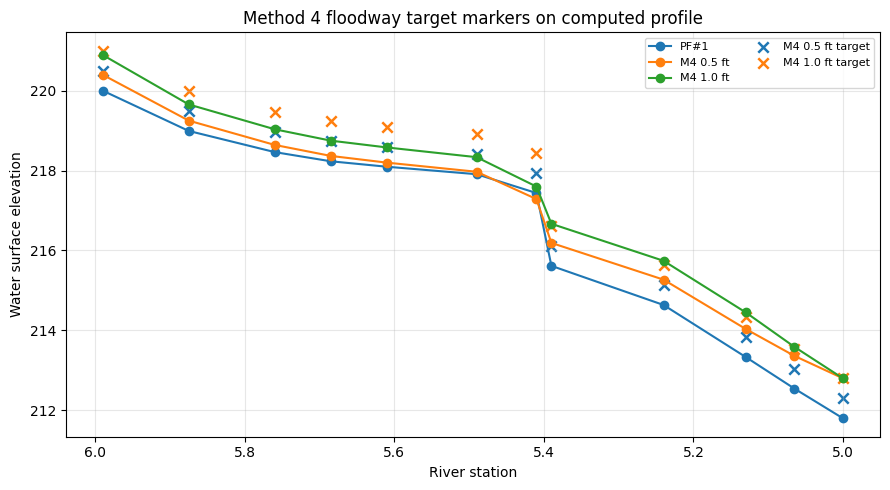

In [5]:
for plan_number in sorted({info["plan"] for info in authored_plans.values()}):
    result = RasCmdr.compute_plan(
        plan_number,
        ras_object=ras_project,
        clear_geompre=True,
        force_rerun=True,
        num_cores=1,
        verify=True,
    )
    assert result, f"HEC-RAS plan {plan_number} failed"

m4_hdf = hdf_plan_path(plan_m4)
m4_results = HdfResultsPlan.get_steady_results(m4_hdf)
m4_results["station_num"] = m4_results["node_id"].map(clean_station)
m4_results = m4_results.sort_values("station_num")

m4_profiles = ["PF#1", *m4_result["new_profile_names"]]
fig, ax = plt.subplots(figsize=(9, 5))
for profile in m4_profiles:
    data = m4_results[m4_results["profile"] == profile]
    ax.plot(data["station_num"], data["wsel"], marker="o", linewidth=1.5, label=profile)

base = (
    m4_results[m4_results["profile"] == "PF#1"]
    [["node_id", "wsel"]]
    .rename(columns={"wsel": "base_wsel"})
)
m4_targets = m4_result["encroachments"].copy()
m4_targets = m4_targets[m4_targets["method"] == 4]
m4_targets["station_num"] = m4_targets["node"].map(clean_station)
m4_targets = m4_targets.merge(base, left_on="node", right_on="node_id", how="inner")
m4_targets["target_wsel"] = m4_targets["base_wsel"] + m4_targets["target_surcharge"]
profile_name_by_number = {
    number: name for number, name in zip(m4_result["new_profile_numbers"], m4_result["new_profile_names"])
}

for profile_number, target_data in m4_targets.groupby("profile_number"):
    profile_name = profile_name_by_number.get(profile_number, f"Profile {profile_number}")
    ax.scatter(
        target_data["station_num"],
        target_data["target_wsel"],
        s=56,
        marker="x",
        linewidths=1.8,
        label=f"{profile_name} target",
    )

ax.set_xlabel("River station")
ax.set_ylabel("Water surface elevation")
ax.set_title("Method 4 floodway target markers on computed profile")
ax.invert_xaxis()
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## Post-Run Floodway Validation

The authoring API delegates post-run checks to `RasCheck.check_floodways`.

In [6]:
validation = RasFloodway.check_floodway(
    hdf_plan_path(plan_m5),
    hdf_geom_path(),
    base_profile="PF#1",
    floodway_profile="M5 1.0 ft",
    surcharge_limit=1.0,
)
print(validation)

validation_rows = [
    {
        "message_id": message.message_id,
        "severity": message.severity.value,
        "river": message.river,
        "reach": message.reach,
        "station": message.station,
        "value": message.value,
        "threshold": message.threshold,
    }
    for message in validation.messages
]
validation_df = pd.DataFrame(validation_rows)
if validation_df.empty:
    print("No floodway messages returned.")
else:
    display(validation_df.groupby(["severity", "message_id"]).size().reset_index(name="count"))
    display(validation_df.head(10))

2026-05-01 17:08:02 - ras_commander.hdf.HdfResultsPlan - INFO - Using existing Path object HDF file: H:\Symphony\ras-commander\CLB-307\notebook_runs\223_steady_floodway_encroachment\Example 6 - Floodway Determination_api_authoring\FLODENCR.p10.hdf


2026-05-01 17:08:02 - ras_commander.hdf.HdfResultsPlan - INFO - Final validated file path: H:\Symphony\ras-commander\CLB-307\notebook_runs\223_steady_floodway_encroachment\Example 6 - Floodway Determination_api_authoring\FLODENCR.p10.hdf


2026-05-01 17:08:02 - ras_commander.hdf.HdfResultsPlan - INFO - Extracted steady results: 48 rows (4 profiles x 12 cross sections)


CheckResults(messages=9, errors=0, warnings=6)


,severity,message_id,count
0,INFO,FW_SC_04,1
1,INFO,FW_SW_01,1
2,INFO,FW_SW_04,1
3,WARNING,FW_SC_02,5
4,WARNING,FW_SW_02,1


,message_id,severity,river,reach,station,value,threshold
0,FW_SC_02,WARNING,Beaver Creek,Kentwood,5.76,-0.048401,NaN
1,FW_SC_02,WARNING,Beaver Creek,Kentwood,5.685*,-0.169479,NaN
2,FW_SC_02,WARNING,Beaver Creek,Kentwood,5.61,-0.199219,NaN
3,FW_SC_02,WARNING,Beaver Creek,Kentwood,5.49*,-0.270981,NaN
4,FW_SC_02,WARNING,Beaver Creek,Kentwood,5.41,-0.413177,NaN
5,FW_SC_04,INFO,Beaver Creek,Kentwood,5.0,1.000000,1.0
6,FW_SW_01,INFO,Beaver Creek,Kentwood,5.0,212.800003,NaN
7,FW_SW_02,WARNING,Beaver Creek,Kentwood,5.0,1.000000,0.5
8,FW_SW_04,INFO,Beaver Creek,Kentwood,5.0,212.800003,209.0


## Floodway Width Comparison

The HDF results contain computed left and right encroachment stations. Floodway width is the right station minus the left station for each floodway profile.

,method,profile,sections,min_width,mean_width,max_width
0,Method 1,PF#2,12,595.570007,750.859155,928.580017
1,Method 2,PF#2,12,595.570007,750.859166,928.580048
2,Method 3,PF#2,12,316.928284,673.654467,923.495331
3,Method 4 0.5 ft,M4 0.5 ft,12,723.146011,1016.333434,1231.000229
4,Method 4 1.0 ft,M4 1.0 ft,12,545.861938,796.217590,1012.513153
5,Method 5 0.5 ft,M5 0.5 ft,12,927.595673,1310.597802,1888.000000
6,Method 5 1.0 ft,M5 1.0 ft,12,951.212189,1374.329582,1788.000000


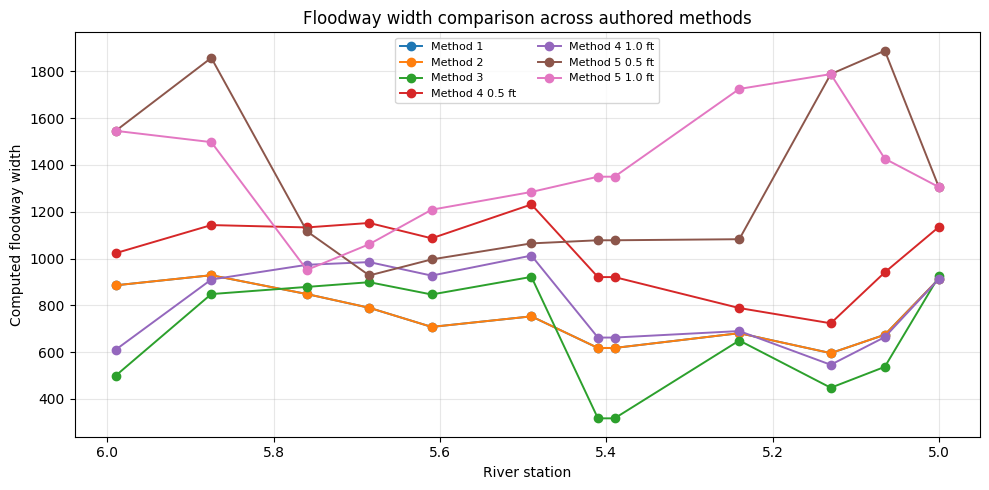

In [7]:
def decode(value):
    if isinstance(value, bytes):
        return value.decode("utf-8").strip()
    return str(value).strip()


def xs_attr_value(attr, *names):
    for name in names:
        if name in attr.dtype.names:
            return decode(attr[name])
    return ""


def extract_floodway_widths(plan_hdf: Path, method_label: str, profile_name: str) -> pd.DataFrame:
    base = "Results/Steady/Output/Output Blocks/Base Output/Steady Profiles"
    add = f"{base}/Cross Sections/Additional Variables"
    with h5py.File(plan_hdf, "r") as hdf:
        profiles = [decode(name) for name in hdf[f"{base}/Profile Names"][()]]
        profile_index = profiles.index(profile_name)
        left = hdf[f"{add}/Encroachment Station Left"][()]
        right = hdf[f"{add}/Encroachment Station Right"][()]
        top_width = hdf[f"{add}/Top Width Total"][()]
        attrs_path = "Results/Steady/Output/Geometry Info/Cross Section Attributes"
        attrs = hdf[attrs_path][()]

        rows = []
        for xs_index, attr in enumerate(attrs):
            encr_left = float(left[profile_index, xs_index])
            encr_right = float(right[profile_index, xs_index])
            width = encr_right - encr_left
            rows.append({
                "method": method_label,
                "profile": profile_name,
                "river": xs_attr_value(attr, "River"),
                "reach": xs_attr_value(attr, "Reach"),
                "station": xs_attr_value(attr, "Station", "RS"),
                "station_num": clean_station(xs_attr_value(attr, "Station", "RS")),
                "encroach_left": encr_left,
                "encroach_right": encr_right,
                "floodway_width": width if width > 0 else pd.NA,
                "top_width_total": float(top_width[profile_index, xs_index]),
            })
    return pd.DataFrame(rows)


width_frames = []
for label, info in authored_plans.items():
    width_frames.append(
        extract_floodway_widths(
            hdf_plan_path(info["plan"]),
            method_label=label,
            profile_name=info["floodway_profile"],
        )
    )

widths = pd.concat(width_frames, ignore_index=True)
width_summary = (
    widths.dropna(subset=["floodway_width"])
    .groupby(["method", "profile"], as_index=False)
    .agg(
        sections=("station", "count"),
        min_width=("floodway_width", "min"),
        mean_width=("floodway_width", "mean"),
        max_width=("floodway_width", "max"),
    )
)
display(width_summary)

fig, ax = plt.subplots(figsize=(10, 5))
for (method, profile), data in widths.dropna(subset=["floodway_width"]).groupby(["method", "profile"]):
    data = data.sort_values("station_num")
    ax.plot(data["station_num"], data["floodway_width"], marker="o", linewidth=1.4, label=method)

ax.set_xlabel("River station")
ax.set_ylabel("Computed floodway width")
ax.set_title("Floodway width comparison across authored methods")
ax.invert_xaxis()
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()